In [1]:
!pip install -q transformers datasets accelerate bitsandbytes peft trl
!pip install -q qwen-vl-utils torchvision

!pip install unsloth
!pip install --no-deps "unsloth[kaggle] @ git+https://github.com/unslothai/unsloth.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 55.6 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 29.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 104.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 111.3 MB/s eta 0:00:00


In [2]:
import glob
import os
from datasets import Dataset

# Dataset Prepartion

In [3]:

root = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"
all_pngs = glob.glob(f"{root}/**/*.png", recursive=True)

pairs = []
for img in all_pngs:
    mmd = img.replace(".png", ".mmd")
    if os.path.exists(mmd):
        with open(mmd, "r", encoding="utf-8") as f:
            pairs.append({"image_path": img, "markdown": f.read()})

full_dataset = Dataset.from_list(pairs)
splits       = full_dataset.train_test_split(test_size=0.2, seed=42)

train_pool = splits["train"]
val_pool   = splits["test"]

n_train = min(2500, len(train_pool))
n_val   = min(300,  len(val_pool))

train_subset = train_pool.select(range(n_train))
val_subset   = val_pool.select(range(n_val))

print(f"total pairs found   : {len(full_dataset)}")
print(f"train pool          : {len(train_pool)}  →  using {n_train}")
print(f"val pool            : {len(val_pool)}   →  using {n_val}")

total pairs found   : 14236
train pool          : 11388  →  using 2500
val pool            : 2848   →  using 300


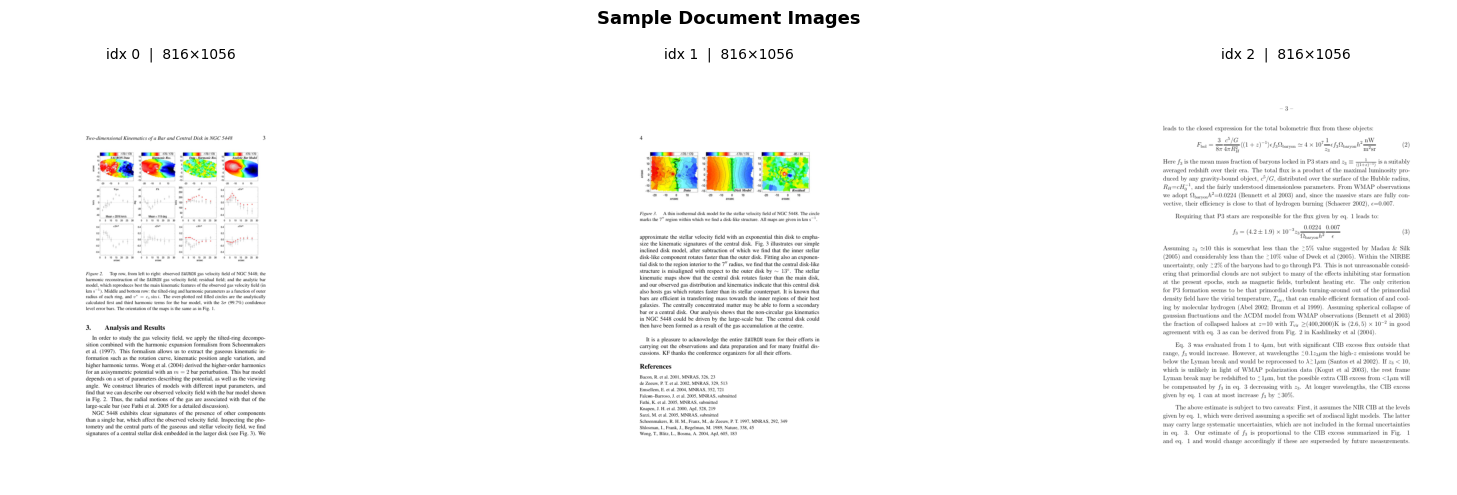


 sample 0 markdown preview 


## 3 Analysis and Results

In order to study the gas velocity field, we apply the tilted-ring decomposition combined with the harmonic expansion formalism from Schoenmakers et al. (1997). This formalism allows us to extract the gaseous kinematic information such as the rotation curve, kinematic position angle variation, and higher harmonic terms. Wong et al. (2004) derived the higher-order harmo
...

 sample 1 markdown preview 
approximate the stellar velocity field with an exponential thin disk to emphasize the kinematic signatures of the central disk. Fig. 3 illustrates our simple inclined disk model, after subtraction of which we find that the inner stellar disk-like component rotates faster than the outer disk. Fitting also an exponential disk to the region interior to the 7\({}^{\prime\prime}\) radius, we find that 
...

 sample 2 markdown preview 
leads to the closed expression for the total bolometric flux from these objects:

\[F_{\rm bol}=\frac{3

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

peek_indices = [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, idx in zip(axes, peek_indices):
    sample = full_dataset[idx]
    img    = Image.open(sample["image_path"])
    ax.imshow(img)
    ax.set_title(f"idx {idx}  |  {img.size[0]}×{img.size[1]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Document Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for idx in peek_indices:
    sample = full_dataset[idx]
    print(f"\n sample {idx} markdown preview ")
    print(sample["markdown"][:400])
    print("...")

In [5]:
# # define a function to convert our data to chatml which is chat markup language

# def format_chatml(example):
#     messages=[
#         {"role":"user",
#         "content":[
#             {"type":"image","image":example["image"]},
#             {"type":"text","text":"Convert this document image into structured Markdown documentation. "}
#         ]
        
#         },
#         {
#             "role":"assistant",
#             "content":[

#                 {"type":"text",
#                 "text":example["markdown"]}
                
#             ]
#         }
#     ]
#     return {"messages",messages}

# train_data=train_data.map(format_chatml)
# val_data=val_data.map(format_chatml)

# print("Data sucessfully formatted into ChatML!")

# Setting up model for fine tuning

In [6]:
from unsloth import FastVisionModel
import torch

model_name = "unsloth/Qwen2-VL-2B-Instruct"
model, processor = FastVisionModel.from_pretrained(
    model_name,
    load_in_4bit=True, 
    use_gradient_checkpointing="unsloth" # A special trick to save even more memory
)


model = FastVisionModel.get_peft_model(
    model,
    r=8, 
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"], # Parts of the brain to train
    finetune_vision_layers=False,
    finetune_language_layers=True
)


print("Unsloth Model loaded and ready to learn super fast!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Unsloth Model loaded and ready to learn super fast!


In [7]:
from PIL import Image
import random
def is_valid_image(example):
    try:
        with Image.open(example["image_path"]) as img:
            img.verify()
        return True
    except Exception:
        return False

random.seed(42)

train_indices = random.sample(range(len(train_pool)), min(2000, len(train_pool)))
val_indices   = random.sample(range(len(val_pool)),   min(100, len(val_pool)))

train_trimmed = train_pool.select(train_indices).filter(is_valid_image)
val_trimmed   = val_pool.select(val_indices).filter(is_valid_image)

print(f"after filter  train: {len(train_trimmed)}  |  val: {len(val_trimmed)}")

TARGET_RES = 512

def resize_if_needed(img):
    w, h  = img.size
    if max(w, h) > TARGET_RES:
        ratio = TARGET_RES / max(w, h)
        img   = img.resize((int(w * ratio), int(h * ratio)), Image.LANCZOS)
    return img

def build_cache(dataset, label):
    cache   = []
    skipped = 0
    for i, sample in enumerate(dataset):
        try:
            img = Image.open(sample["image_path"]).convert("RGB")
            img = resize_if_needed(img)
            cache.append({"image": img, "markdown": sample["markdown"]})
        except Exception:
            skipped += 1
            continue
        if i % 100 == 0:
            print(f"{label}  {i}/{len(dataset)}  skipped: {skipped}")
    print(f"{label} done  loaded: {len(cache)}  skipped: {skipped}")
    return cache

print("building cache...")
train_cache = build_cache(train_trimmed, "train")
val_cache   = build_cache(val_trimmed,   "val")

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

after filter  train: 1995  |  val: 100
building cache...
train  0/1995  skipped: 0
train  100/1995  skipped: 0
train  200/1995  skipped: 0
train  300/1995  skipped: 0
train  400/1995  skipped: 0
train  500/1995  skipped: 0
train  600/1995  skipped: 0
train  700/1995  skipped: 0
train  800/1995  skipped: 0
train  900/1995  skipped: 0
train  1000/1995  skipped: 0
train  1100/1995  skipped: 0
train  1200/1995  skipped: 0
train  1300/1995  skipped: 0
train  1400/1995  skipped: 0
train  1500/1995  skipped: 0
train  1600/1995  skipped: 0
train  1700/1995  skipped: 0
train  1800/1995  skipped: 0
train  1900/1995  skipped: 0
train done  loaded: 1995  skipped: 0
val  0/100  skipped: 0
val done  loaded: 100  skipped: 0


# Training Config and Loops

In [8]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
from PIL import Image
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

torch.cuda.empty_cache()

class CachedFormatDataset(torch.utils.data.Dataset):
    def __init__(self, cache):
        self.cache = cache

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        entry = self.cache[idx]
        return {
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": entry["image"]},
                        {"type": "text",  "text": "Convert this document into Markdown."}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": entry["markdown"]}]
                }
            ]
        }

final_train_data = CachedFormatDataset(train_cache)
final_val_data   = CachedFormatDataset(val_cache)

print(f"train: {len(final_train_data)}  |  val: {len(final_val_data)}")

training_rules = SFTConfig(
    output_dir                  = "./results",
    num_train_epochs            = 2,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 8,
    learning_rate               = 1e-4,
    fp16                        = True,
    bf16                        = False,
    logging_steps               = 35,
    eval_strategy               = "no",
    save_strategy               = "epoch",
    report_to                   = "none",
    remove_unused_columns       = False,
    dataloader_pin_memory       = False,
    dataset_kwargs              = {"skip_prepare_dataset": True},
)

trainer = SFTTrainer(
    model         = model,
    tokenizer     = processor,
    data_collator = UnslothVisionDataCollator(model, processor),
    train_dataset = final_train_data,
    eval_dataset  = final_val_data,
    args          = training_rules,
)

trainer.train()
model.save_pretrained("./my_unsloth_qwen")
processor.save_pretrained("./my_unsloth_qwen")
print("training done")

train: 1995  |  val: 100
Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,995 | Num Epochs = 2 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 2,179,072 of 2,211,164,672 (0.10% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
20,0.619432
40,0.556789
60,0.479820
80,0.517159
100,0.459974
120,0.452949
140,0.448639
160,0.440286
180,0.440406
200,0.438860


Unsloth: Restored added_tokens_decoder metadata in ./results/checkpoint-125/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./results/checkpoint-250/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./my_unsloth_qwen/tokenizer_config.json.


training done


In [12]:
import torch
from torch.utils.data import DataLoader
from unsloth.trainer import UnslothVisionDataCollator

torch.cuda.empty_cache()

val_loader = DataLoader(
    final_val_data,
    batch_size  = 1,
    collate_fn  = UnslothVisionDataCollator(model, processor)
)

model.eval()
total_loss = 0
count      = 0

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to("cuda") if hasattr(v, "to") else v for k, v in batch.items()}
        out    = model(**batch)
        total_loss += out.loss.item()
        count      += 1
        if count % 10 == 0:
            print(f"{count}/{len(val_loader)}  running loss: {total_loss/count:.4f}")

val_loss = total_loss / count
print(f"\nfinal val loss: {val_loss:.4f}")

Unsloth: Model does not have a default image size - using 512
10/100  running loss: 0.3875
20/100  running loss: 0.3740
30/100  running loss: 0.3918
40/100  running loss: 0.3728
50/100  running loss: 0.3671
60/100  running loss: 0.3868
70/100  running loss: 0.3760
80/100  running loss: 0.3897
90/100  running loss: 0.3762
100/100  running loss: 0.3828

final val loss: 0.3828


# Loss Graph

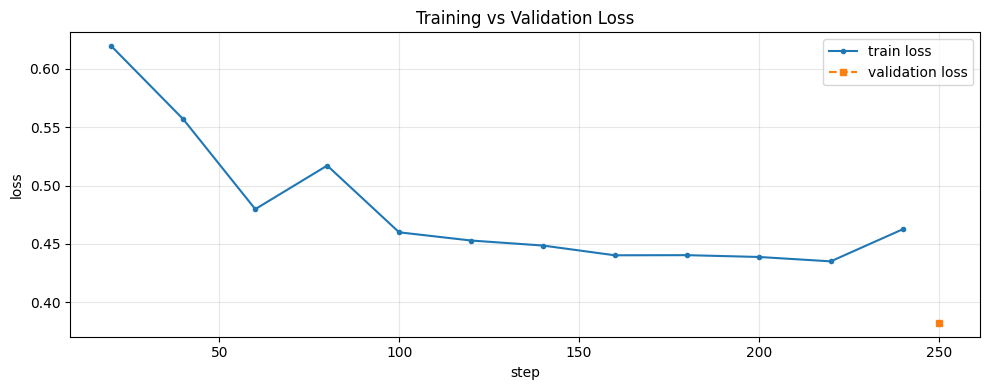

best val loss  : 0.3824
final train loss: 0.4626


In [16]:
import matplotlib.pyplot as plt

logs       = trainer.state.log_history
train_logs = [(x["step"], x["loss"])      for x in logs if "loss" in x and "eval_loss" not in x]
eval_logs  = [(x["step"], x["eval_loss"]) for x in logs if "eval_loss" in x]

t_steps, t_loss = zip(*train_logs) if train_logs else ([], [])
e_steps, e_loss = zip(*eval_logs)  if eval_logs  else ([], [])

plt.figure(figsize=(10, 4))
plt.plot(t_steps, t_loss, label="train loss",      marker="o", markersize=3)
plt.plot(e_steps, e_loss, label="validation loss", marker="s", markersize=5, linestyle="--")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print(f"best val loss  : {min(e_loss):.4f}" if e_loss else "no eval logs found")
print(f"final train loss: {t_loss[-1]:.4f}" if t_loss else "no train logs found")

In [27]:
from unsloth import FastVisionModel
import torch

FastVisionModel.for_inference(model)

def run_model(img, max_tokens=512):
    if not isinstance(img, Image.Image):
        img = Image.open(img).convert("RGB")
    msgs   = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Convert this document into Markdown."}
        ]
    }]
    prompt  = processor.apply_chat_template(msgs, add_generation_prompt=True)
    inputs  = processor(text=prompt, images=[img], return_tensors="pt").to("cuda")
    inp_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_tokens)
    return processor.decode(out[0][inp_len:], skip_special_tokens=True)

val_results = []
for i in range(3):
    entry = val_cache[i]
    pred  = run_model(entry["image"])
    val_results.append({
        "image"        : entry["image"],
        "ground_truth" : entry["markdown"],
        "predicted"    : pred
    })
    print(f"val sample {i} done")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


val sample 0 done


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


val sample 1 done


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


val sample 2 done


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


val sample 3 done
val sample 4 done


# Comparison

In [31]:
import os
import glob

os.makedirs("/kaggle/working/unseen", exist_ok=True)

if len(glob.glob("/kaggle/working/unseen/*.png")) == 0:
    for i, entry in enumerate(val_cache[10:13]):
        entry["image"].save(f"/kaggle/working/unseen/unseen_{i}.png")
    print("created 3 unseen images from val cache")

test_results = []

for i in range(3):
    entry = train_cache[i]
    pred  = run_model(entry["image"])
    test_results.append({
        "image"        : entry["image"],
        "ground_truth" : entry["markdown"],
        "predicted"    : pred,
        "split"        : "train"
    })
    print(f"train sample {i} done")

unseen_paths = glob.glob("/kaggle/working/unseen/*.png")[:3]
for path in unseen_paths:
    img  = Image.open(path).convert("RGB")
    pred = run_model(img)
    test_results.append({
        "image"        : img,
        "ground_truth" : "N/A",
        "predicted"    : pred,
        "split"        : "unseen"
    })
    print(f"unseen {os.path.basename(path)} done")

print(f"total test results: {len(test_results)}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


created 3 unseen images from val cache


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


train sample 0 done


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

train sample 2 done


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


unseen unseen_0.png done


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


unseen unseen_1.png done
unseen unseen_2.png done
total test results: 6


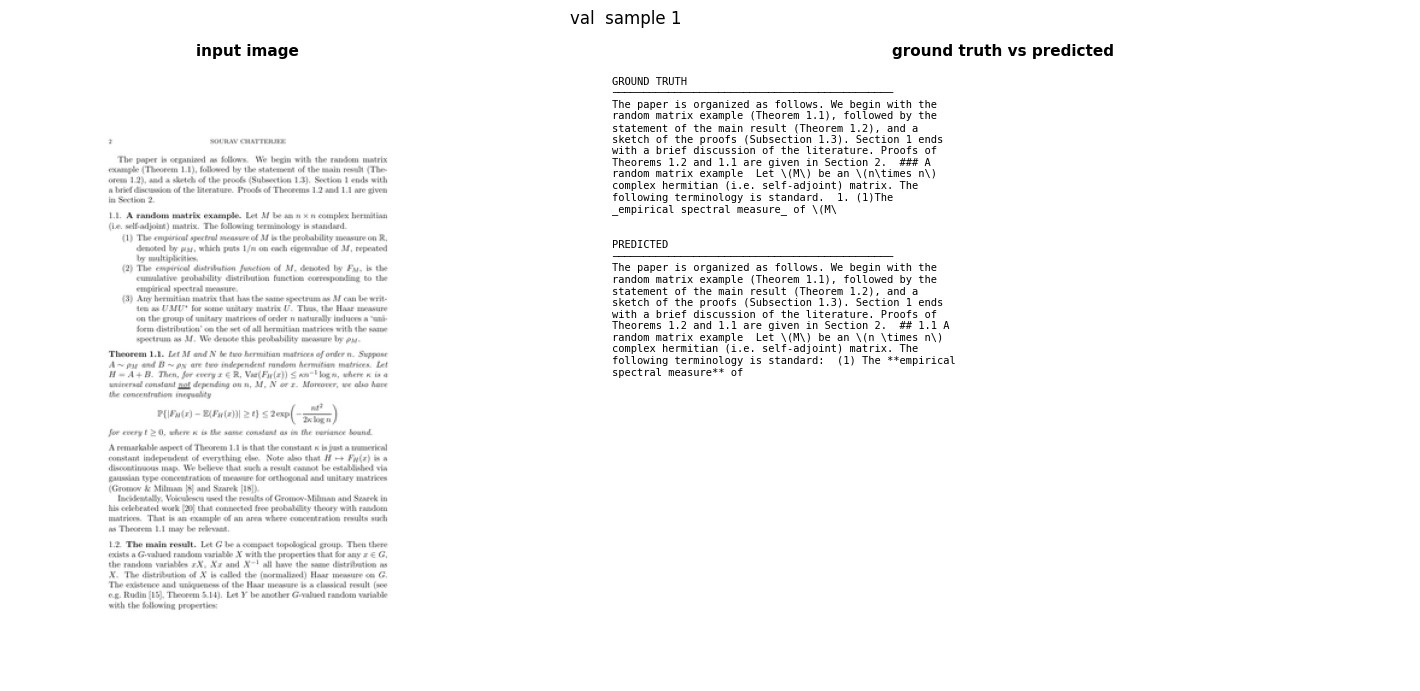

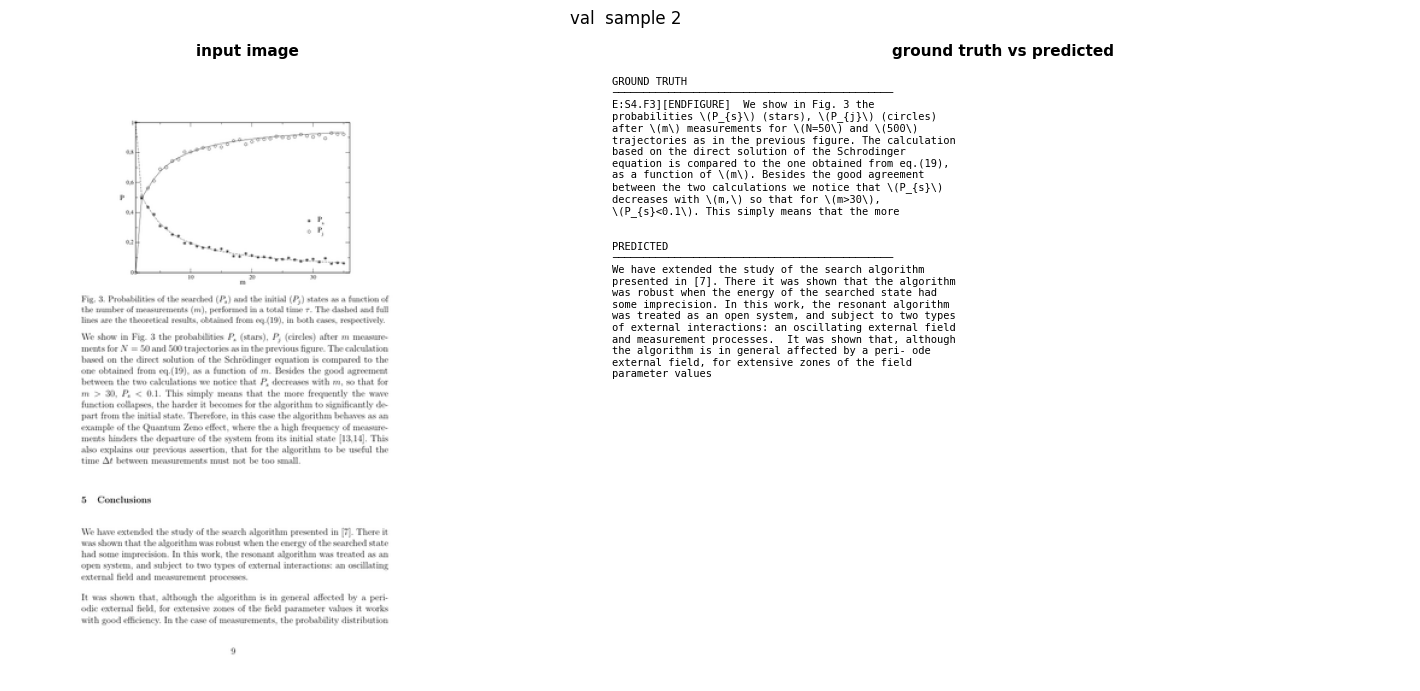

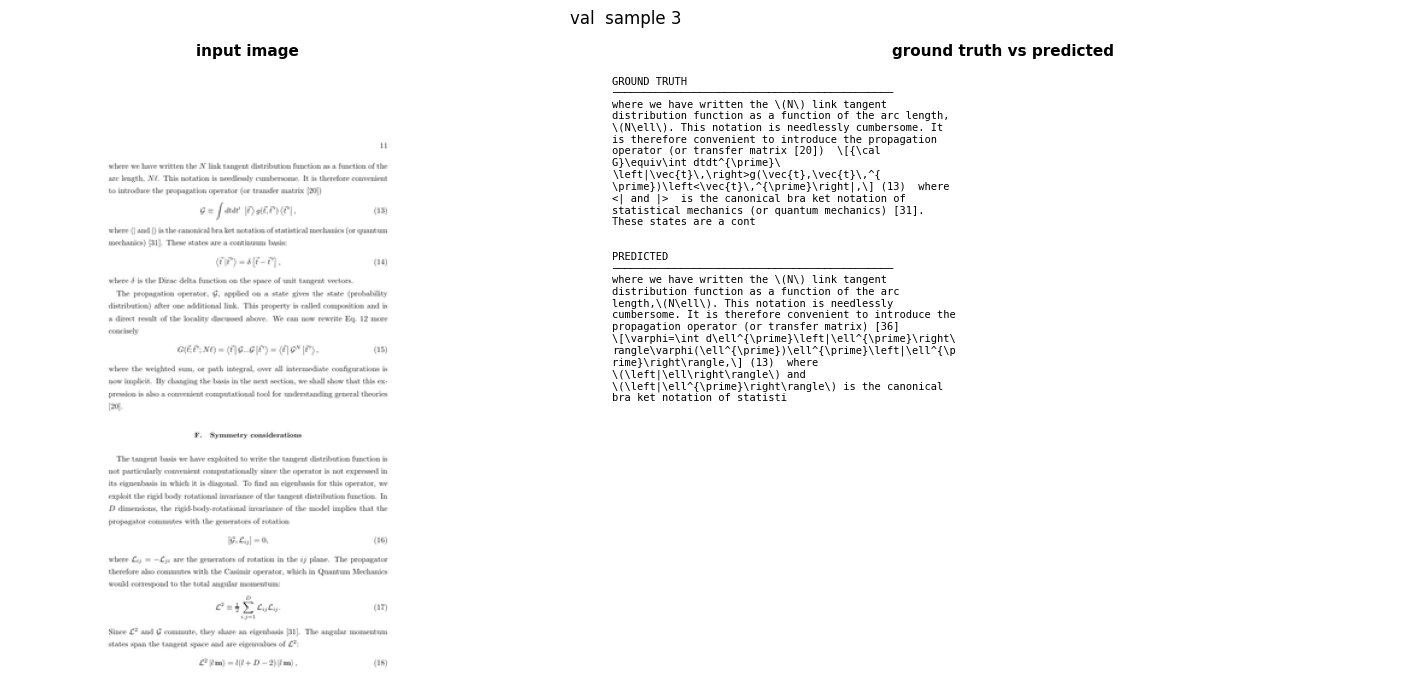

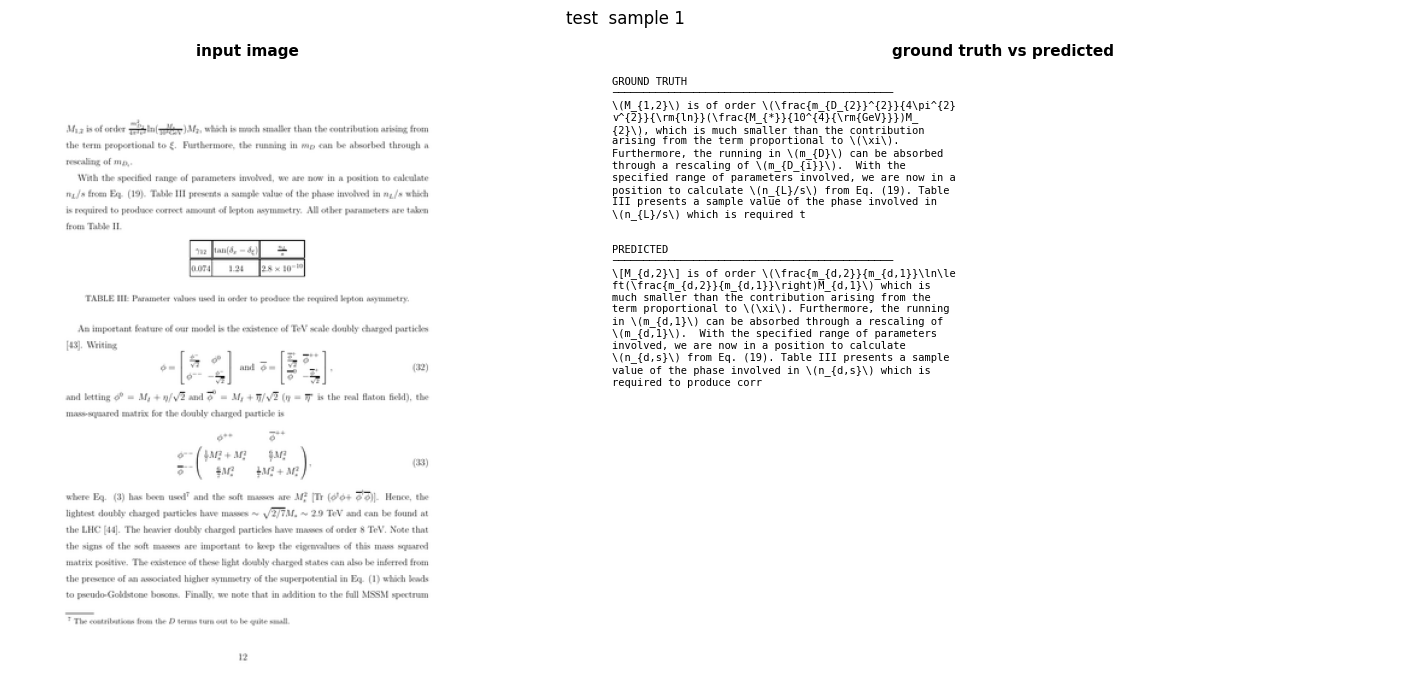

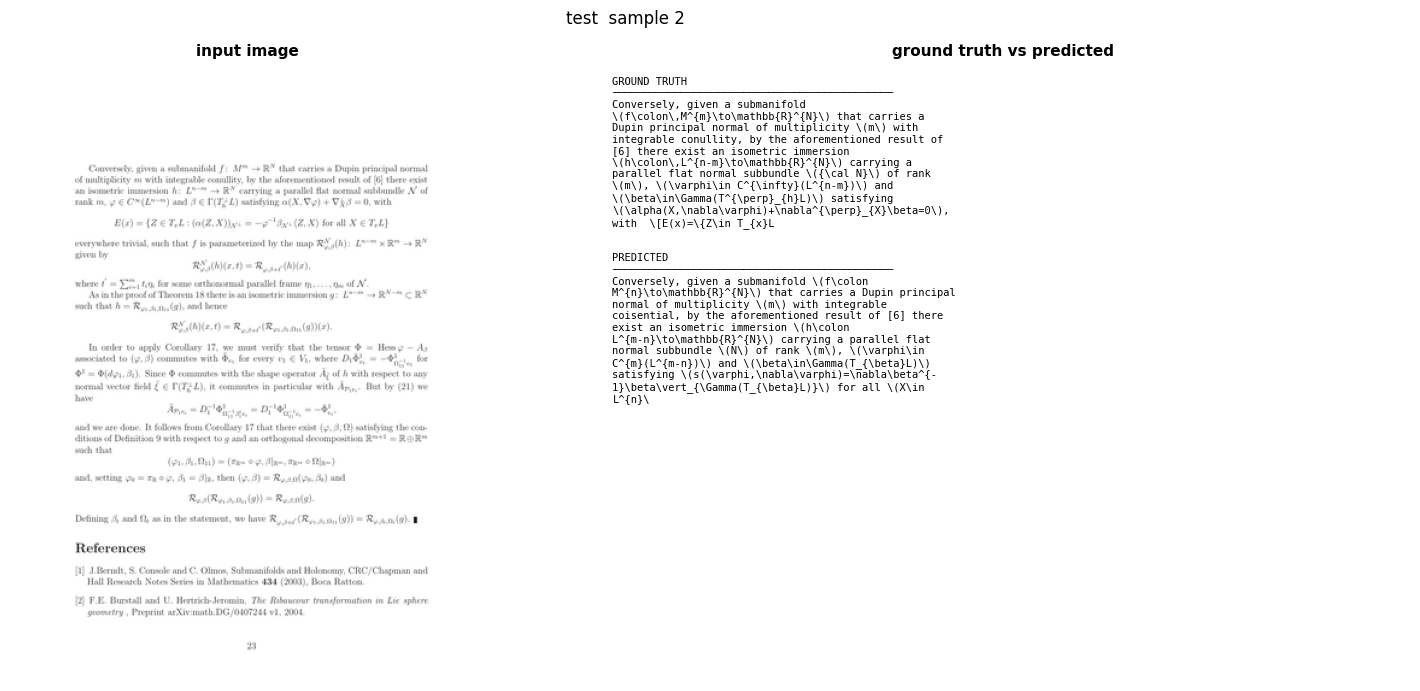

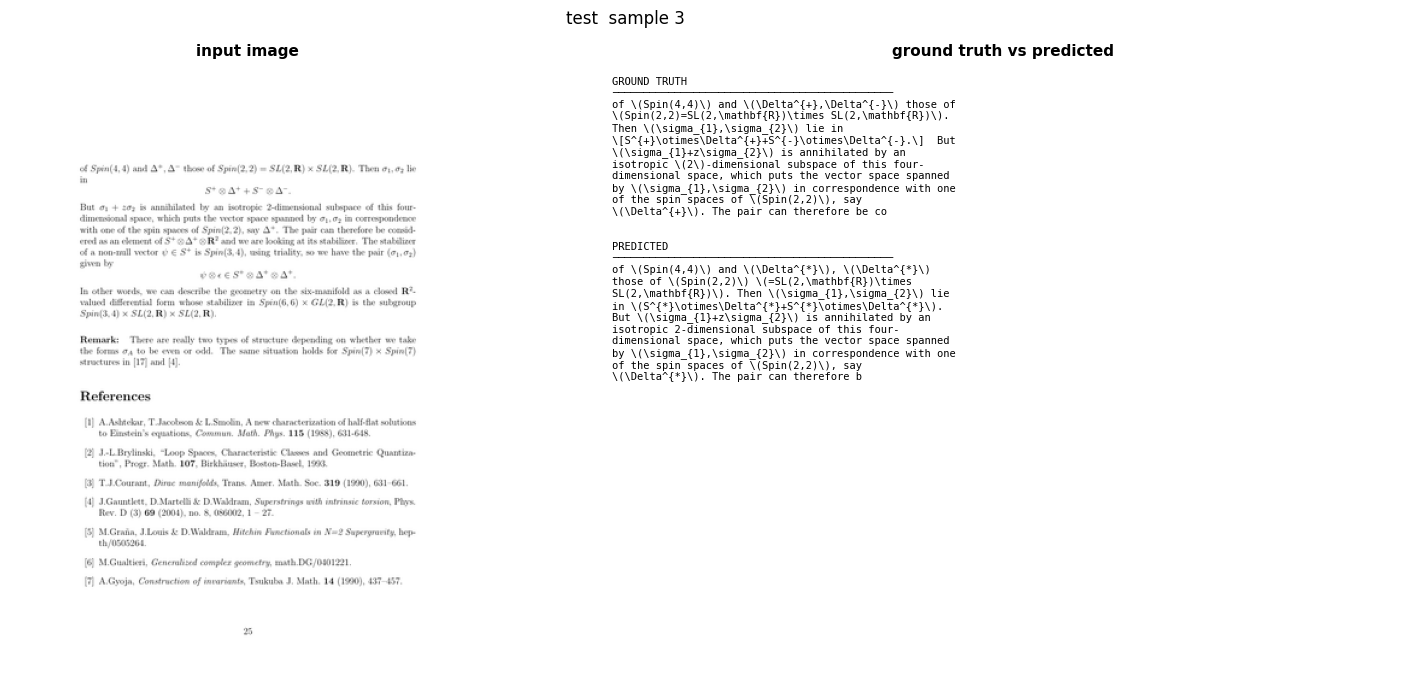

In [33]:
import matplotlib.pyplot as plt
import textwrap

def show_comparison(results, title=""):
    for i, r in enumerate(results[:3]):
        fig, (ax_img, ax_text) = plt.subplots(1, 2, figsize=(16, 7))

        ax_img.imshow(r["image"])
        ax_img.set_title("input image", fontsize=11, fontweight="bold")
        ax_img.axis("off")

        gt   = "\n".join(textwrap.wrap(r["ground_truth"][:500], 55))
        pred = "\n".join(textwrap.wrap(r["predicted"][:500],    55))
        body = f"GROUND TRUTH\n{'─'*45}\n{gt}\n\n\nPREDICTED\n{'─'*45}\n{pred}"

        ax_text.text(0.02, 0.98, body, transform=ax_text.transAxes,
                     fontsize=7.5, verticalalignment="top", fontfamily="monospace")
        ax_text.axis("off")
        ax_text.set_title("ground truth vs predicted", fontsize=11, fontweight="bold")

        plt.suptitle(f"{title}  sample {i+1}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"viz_{title}_{i+1}.png", dpi=150, bbox_inches="tight")
        plt.show()

show_comparison(val_results,  title="val")
show_comparison(test_results, title="test")

# Gradio

In [34]:
!pip install -q gradio

import gradio as gr
import tempfile

def predict(image):
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        image.save(tmp.name)
        output = run_model(tmp.name)
    return output

app = gr.Interface(
    fn          = predict,
    inputs      = gr.Image(type="pil", label="upload document image"),
    outputs     = gr.Textbox(label="generated markdown", lines=25),
    title       = "document → markdown",
    description = "fine-tuned Qwen2-VL-2B converts document images into structured markdown"
)

app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://960721ac7959d22d75.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [45]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import whoami

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
print(f"token starts with: {hf_token[:8]}...")

try:
    info = whoami(token=hf_token)
    print(f"logged in as: {info['name']}")
except Exception as e:
    print(f"token invalid: {e}")

token starts with: hf_avVPT...
logged in as: hurairamuzammal


# Pushing model to hf

In [50]:
import torch
import os
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

merged = model.merge_and_unload()

os.makedirs("merged_upload", exist_ok=True)

merged.config.save_pretrained("merged_upload")
processor.save_pretrained("merged_upload")

state_dict = {}
for k, v in merged.named_parameters():
    state_dict[k] = v.detach().cpu().to(torch.float16)

from safetensors.torch import save_file
save_file(state_dict, "merged_upload/model.safetensors")
print("merged model saved locally")

import shutil
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"disk  used: {used/1e9:.1f}GB  free: {free/1e9:.1f}GB")

Unsloth: Restored added_tokens_decoder metadata in merged_upload/tokenizer_config.json.


merged model saved locally
disk  used: 3.2GB  free: 17.7GB


In [51]:
api.create_repo(
    "hurairamuzammal/qwen2-2b-vl-merged",
    token    = hf_token,
    exist_ok = True
)

api.upload_folder(
    folder_path = "merged_upload",
    repo_id     = "hurairamuzammal/qwen2-2b-vl-merged",
    token       = hf_token,
    repo_type   = "model"
)
print("merged model uploaded → https://huggingface.co/hurairamuzammal/qwen2-2b-vl-merged")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

merged model uploaded → https://huggingface.co/hurairamuzammal/qwen2-2b-vl-merged


In [52]:
app_code = '''
import gradio as gr
import torch
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

model_id = "hurairamuzammal/qwen2-2b-vl-merged"

print("loading model...")
processor = AutoProcessor.from_pretrained(model_id)
model     = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map  = "auto"
)
model.eval()
print("model ready")

def predict(image):
    if image is None:
        return "please upload an image"
    img  = image.convert("RGB")
    msgs = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Convert this document into Markdown."}
        ]
    }]
    prompt  = processor.apply_chat_template(msgs, add_generation_prompt=True)
    inputs  = processor(text=prompt, images=[img], return_tensors="pt").to(model.device)
    inp_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=512)
    return processor.decode(out[0][inp_len:], skip_special_tokens=True)

gr.Interface(
    fn          = predict,
    inputs      = gr.Image(type="pil", label="upload document image"),
    outputs     = gr.Textbox(label="generated markdown", lines=25),
    title       = "document to markdown",
    description = "qwen2-vl-2b fine-tuned on nougat dataset"
).launch()
'''

requirements = """gradio
torch
transformers>=4.45.0
Pillow
accelerate
qwen-vl-utils
"""

with open("app.py", "w") as f:
    f.write(app_code)

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("app files created")

from huggingface_hub import HfApi
from kaggle_secrets import UserSecretsClient

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
api      = HfApi()

for fname in ["app.py", "requirements.txt"]:
    api.upload_file(
        path_or_fileobj = fname,
        path_in_repo    = fname,
        repo_id         = "hurairamuzammal/qwen2-vl-document-ocr",
        repo_type       = "space",
        token           = hf_token
    )

print("space updated → https://huggingface.co/spaces/hurairamuzammal/qwen2-vl-document-ocr")

app files created
space updated → https://huggingface.co/spaces/hurairamuzammal/qwen2-vl-document-ocr
